In [3]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Data_sets/house_data.csv'
#load data
import pandas as pd
df = pd.read_csv(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
x=df.drop('price',,axis=1)
y=df['price']


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [8]:
#desicion tree
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=3, random_state=42)

# Drop non-numeric columns that are not suitable for direct use in the model
columns_to_drop = ['date', 'street', 'city', 'statezip', 'country']

x_train_processed = x_train.drop(columns=columns_to_drop, axis=1, errors='ignore')
x_test_processed = x_test.drop(columns=columns_to_drop, axis=1, errors='ignore')

model.fit(x_train_processed,y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [10]:
#random forest
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100,random_state=42)

# Drop non-numeric columns that are not suitable for direct use in the model
columns_to_drop = ['date', 'street', 'city', 'statezip', 'country']

x_train_processed = x_train.drop(columns=columns_to_drop, axis=1, errors='ignore')
x_test_processed = x_test.drop(columns=columns_to_drop, axis=1, errors='ignore')

model.fit(x_train_processed,y_train)

RandomForestRegressor(random_state=42)

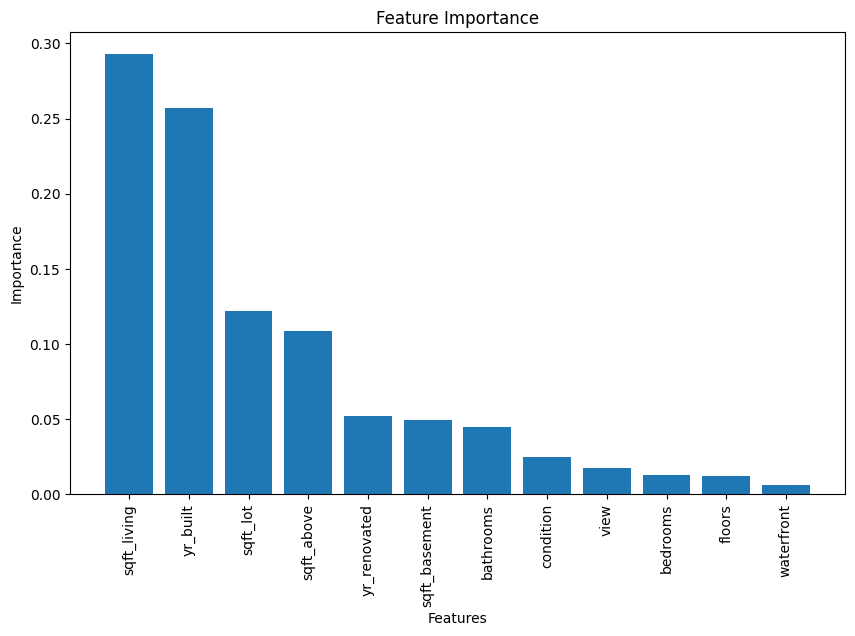

In [12]:
#plot for random forest
import matplotlib.pyplot as plt
import numpy as np
feature_importances = model.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(x_train_processed.shape[1]), feature_importances[sorted_indices], align='center')
plt.xticks(range(x_train_processed.shape[1]), x_train_processed.columns[sorted_indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

In [14]:
#r2 value and mean square error value for random forest
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test_processed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Random Forest")
print("Mean Squared Error:", mse)
print("R-squared:", r2)



Random Forest
Mean Squared Error: 259687955426.1725
R-squared: -0.7745469521382953


In [15]:
#r2 value and mean square error value for desicion tree
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test_processed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Desicion Tree")
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Desicion Tree
Mean Squared Error: 259687955426.1725
R-squared: -0.7745469521382953


In [ ]:
import pandas as pd

# Define the features the model was trained on
feature_names = x_train_processed.columns.tolist()

# Create a dictionary to store user inputs
user_input = {}

# Prompt the user for each feature value
print("Please enter values for the following features to predict the house price:")
for feature in feature_names:
    while True:
        try:
            value = float(input(f"Enter value for {feature}: "))
            user_input[feature] = value
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# Convert user input to a DataFrame, ensuring column order matches training data
input_df = pd.DataFrame([user_input], columns=feature_names)

# Make a prediction using the trained model
predicted_price = model.predict(input_df)

print(f"\nThe predicted price for the given inputs is: (₹){predicted_price[0]:,.2f}")

Please enter values for the following features to predict the house price:
